In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

print(os.getenv("LANGSMITH_TRACING"))
print(os.getenv("LANGSMITH_ENDPOINT"))
print(os.getenv("LANGSMITH_PROJECT"))
print(os.getenv("LANGSMITH_API_KEY")[:10] + "...")

true
https://api.smith.langchain.com
RAG_POC
lsv2_pt_5c...


## Tracing(Observability)

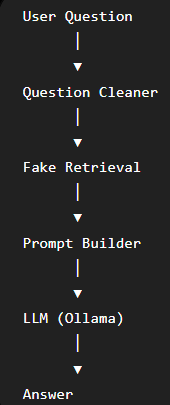

In [2]:
from dotenv import load_dotenv
load_dotenv()

from langsmith import traceable
import ollama
import time

MODEL = "qwen3:8b"


# -------------------------------------------------------
# Step 1 : Question Cleaner
# -------------------------------------------------------

@traceable(
    name="Question Cleaner",
    run_type="chain"
)
def clean_question(question):

    time.sleep(1)

    return question.strip().lower()


# -------------------------------------------------------
# Step 2 : Fake Retrieval
# -------------------------------------------------------

@traceable(
    name="Document Retrieval",
    run_type="retriever"
)
def retrieve_documents(question):

    time.sleep(2)

    docs = [
        "The Alarm Logger Manager is configured from the Application Bar.",
        "Figure 8-10 shows the Application Bar configuration.",
        "Alarm Logger Manager stores alarm history."
    ]

    return docs


# -------------------------------------------------------
# Step 3 : Prompt Builder
# -------------------------------------------------------

@traceable(
    name="Prompt Builder",
    run_type="prompt"
)
def build_prompt(question, docs):

    context = "\n".join(docs)

    prompt = f"""
You are an assistant.

Context:
{context}

Question:
{question}

Answer using only the context.
"""

    return prompt


# -------------------------------------------------------
# Step 4 : LLM
# -------------------------------------------------------

@traceable(
    name="Answer Generation",
    run_type="llm"
)
def generate_answer(prompt):

    response = ollama.chat(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response["message"]["content"]


# -------------------------------------------------------
# Complete Pipeline
# -------------------------------------------------------

@traceable(
    name="Basic RAG Pipeline",
    run_type="chain"
)
def rag_pipeline(question):

    question = clean_question(question)

    docs = retrieve_documents(question)

    prompt = build_prompt(question, docs)

    answer = generate_answer(prompt)

    return answer


# -------------------------------------------------------
# Run
# -------------------------------------------------------

question = "Which figure should I refer to configure Alarm Logger Manager?"

answer = rag_pipeline(question)

print(answer)

Figure 8-10.


# DataSet

In [4]:
from langsmith import Client

client = Client()

dataset = client.create_dataset(
    dataset_name="Calculator Dataset",
    description="Simple calculator testing"
)

print(dataset.id)

7a27c1d1-0eba-4550-b82f-05343ba25044


In [5]:
client.create_examples(
    dataset_id=dataset.id,

    inputs=[
        {"question":"2 + 2"},
        {"question":"10 + 15"},
        {"question":"100 - 25"}
    ],

    outputs=[
        {"answer":"4"},
        {"answer":"25"},
        {"answer":"75"}
    ]
)

{'example_ids': ['d6a49cd4-5ac8-4b0c-a3c9-421299f634c6',
  '6863bad8-e26c-4576-99ea-4c4c73bb6bf3',
  '33c34bce-ed8c-45c9-81f7-e525592e8372'],
 'count': 3,
 'as_of': '2026-07-27T13:10:20.242743757Z'}

In [8]:
def calculator(question):

    return str(eval(question))

calculator("2+5")

'7'

### Experiments

In [10]:
from langsmith import Client
from langsmith.evaluation import evaluate

client = Client()

def calculator(inputs):

    expression = inputs["question"]

    answer = str(eval(expression))

    return {
        "answer": answer
    }

results = evaluate(

    calculator,

    data="Calculator Dataset",

    experiment_prefix="Calculator-v2",
)

print(results)

View the evaluation results for experiment: 'Calculator-v2-aa6329f2' at:
https://smith.langchain.com/o/fa3d1324-37d3-4d19-bf7e-c4846aca8587/datasets/7a27c1d1-0eba-4550-b82f-05343ba25044/compare?selectedSessions=2399f99e-c611-44ac-b91d-028198703d75




3it [00:00,  7.20it/s]

<ExperimentResults Calculator-v2-aa6329f2>


## Evalution

In [17]:


from langsmith import Client
from langsmith.evaluation import evaluate

# =====================================================
# Create LangSmith Client
# =====================================================

client = Client()

DATASET_NAME = "Calculator Dataset Demo"

# =====================================================
# Create Dataset (only once)
# =====================================================

try:
    dataset = client.create_dataset(
        dataset_name=DATASET_NAME,
        description="Simple calculator evaluation demo"
    )
    print("Dataset created.")

    client.create_examples(
        dataset_id=dataset.id,

        inputs=[
            {"question": "2+2"},
            {"question": "10*5"},
            {"question": "100/20"},
            {"question": "15-8"},
            {"question": "9*9"},
        ],

        outputs=[
            {"answer": "4"},
            {"answer": "50"},
            {"answer": "5.0"},
            {"answer": "7"},
            {"answer": "81"},
        ]
    )

    print("Examples added.")

except Exception:
    print("Dataset already exists.")

# =====================================================
# Application Under Test
# =====================================================

def calculator(inputs: dict):

    question = inputs["question"]

    answer = str(eval(question))

    return {
        "answer": answer
    }

# =====================================================
# Evaluator 1
# Exact Match
# =====================================================

def exact_match(outputs, reference_outputs):

    score = outputs["answer"] == reference_outputs["answer"]

    return {
        "key": "Exact Match",
        "score": score,
        "comment": (
            "Correct"
            if score
            else "Incorrect"
        )
    }

# =====================================================
# Evaluator 2
# Length Check
# =====================================================

def answer_length(outputs, reference_outputs):

    length = len(outputs["answer"])
    print(length)
    return {
        "key": "Length",
        "score": length,
        "comment": f"Length = {length}"
    }

# =====================================================
# Evaluator 3
# Contains Number
# =====================================================

def contains_digit(outputs, reference_outputs):

    result = any(ch.isdigit() for ch in outputs["answer"])

    return {
        "key": "Contains Digit",
        "score": result
    }

# =====================================================
# Run Experiment
# =====================================================

results = evaluate(

    calculator,

    data=DATASET_NAME,

    evaluators=[
        exact_match,
        answer_length,
        contains_digit
    ],

    experiment_prefix="Calculator-v1"
)

print("\nExperiment Finished Successfully!")
print(results)


Dataset already exists.
View the evaluation results for experiment: 'Calculator-v1-d549ee2b' at:
https://smith.langchain.com/o/fa3d1324-37d3-4d19-bf7e-c4846aca8587/datasets/56b82e39-11b9-48e4-b9e9-84b0a03e212a/compare?selectedSessions=9cf0ee1a-d55f-4567-9a47-1d4d77463ecc




0it [00:00, ?it/s]

1
2
2
3
1


5it [00:00, 12.16it/s]


Experiment Finished Successfully!
<ExperimentResults Calculator-v1-d549ee2b>


In [14]:
calculator({"question": "2+2"})

{'answer': '4'}

In [ ]:
def exact_match(outputs, reference_outputs):

    return {
        "score": outputs["answer"] == reference_outputs["answer"]
    }

outputs["answer"] == reference_outputs["answer"]

## Regration Testing

In [3]:
from dotenv import load_dotenv
load_dotenv()

from langsmith import Client
from langsmith.evaluation import evaluate

# ============================================================
# Dataset
# ============================================================

client = Client()

DATASET_NAME = "Regression Demo Dataset"

try:
    dataset = client.create_dataset(
        dataset_name=DATASET_NAME,
        description="Dataset for regression testing demo"
    )

    client.create_examples(
        dataset_id=dataset.id,
        inputs=[
            {"question": "2+2"},
            {"question": "10*5"},
            {"question": "100/20"},
            {"question": "15-8"},
            {"question": "9*9"},
        ],
        outputs=[
            {"answer": "4"},
            {"answer": "50"},
            {"answer": "500"},
            {"answer": "7"},
            {"answer": "81"},
        ],
    )

    print("Dataset created.")

except Exception:
    print("Dataset already exists.")

# ============================================================
# Version 1 (Correct)
# ============================================================

def calculator_v1(inputs):

    question = inputs["question"]

    answer = str(eval(question))

    return {
        "answer": answer
    }

# ============================================================
# Version 2 (Bug Introduced)
# ============================================================

def calculator_v2(inputs):

    question = inputs["question"]

    answer = str(eval(question))

    # put the llm quetion and answer here
    # Simulate a bug
    if question == "10*5":
        answer = "70"

    return {
        "answer": answer
    }

# ============================================================
# Evaluator
# ============================================================

def exact_match(outputs, reference_outputs):

    score = outputs["answer"] == reference_outputs["answer"]

    return {
        "key": "Exact Match",
        "score": score,
        "comment": (
            "Correct"
            if score
            else "Incorrect"
        )
    }

# ============================================================
# Experiment 1
# ============================================================

print("\nRunning Calculator V1...")

evaluate(
    calculator_v1,
    data=DATASET_NAME,
    evaluators=[exact_match],
    experiment_prefix="Calculator-V1"
)

# ============================================================
# Experiment 2
# ============================================================

print("\nRunning Calculator V2...")

evaluate(
    calculator_v2,
    data=DATASET_NAME,
    evaluators=[exact_match],
    experiment_prefix="Calculator-V2"
)

print("\nRegression Demo Complete.")
print("Open LangSmith and compare Calculator-V1 with Calculator-V2.")

Dataset already exists.

Running Calculator V1...
View the evaluation results for experiment: 'Calculator-V1-3416bcd1' at:
https://smith.langchain.com/o/fa3d1324-37d3-4d19-bf7e-c4846aca8587/datasets/1a69dd80-e5c9-4065-b79e-2935b28865b1/compare?selectedSessions=b9e2eb58-36ff-4c41-b952-96c6459b8d9e




5it [00:00, 15.91it/s]



Running Calculator V2...
View the evaluation results for experiment: 'Calculator-V2-6f421454' at:
https://smith.langchain.com/o/fa3d1324-37d3-4d19-bf7e-c4846aca8587/datasets/1a69dd80-e5c9-4065-b79e-2935b28865b1/compare?selectedSessions=9a8d6a84-e620-43f3-874c-8967ff14ae16




5it [00:00, 15.70it/s]


Regression Demo Complete.
Open LangSmith and compare Calculator-V1 with Calculator-V2.


## LLM-as-a-Judge

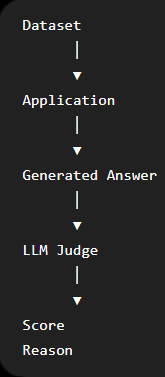

In [4]:
from dotenv import load_dotenv
load_dotenv()

import json
import ollama

from langsmith import Client
from langsmith.evaluation import evaluate

# =====================================================
# Dataset
# =====================================================

client = Client()

DATASET_NAME = "LLM Judge Demo"

try:
    dataset = client.create_dataset(
        dataset_name=DATASET_NAME
    )

    client.create_examples(
        dataset_id=dataset.id,

        inputs=[
            {
                "question":"Who created Python?"
            },
            {
                "question":"Capital of France?"
            }
        ],

        outputs=[
            {
                "answer":"Guido van Rossum"
            },
            {
                "answer":"Paris"
            }
        ]
    )

except Exception:
    print("Dataset already exists.")

# =====================================================
# Application
# =====================================================

def chatbot(inputs):

    question = inputs["question"]

    if "Python" in question:
        answer = "Python was created by Guido van Rossum."

    else:
        answer = "The capital of France is Paris."

    return {
        "answer":answer
    }

# =====================================================
# LLM Judge
# =====================================================

def llm_judge(outputs, reference_outputs, inputs):

    prompt = f"""
You are an expert evaluator.

Question:
{inputs["question"]}

Expected Answer:
{reference_outputs["answer"]}

Generated Answer:
{outputs["answer"]}

Evaluate whether the generated answer correctly answers the question.

Return ONLY valid JSON.

{{
    "score": 1 or 0,
    "reason": "short explanation"
}}
"""

    response = ollama.chat(
        model="qwen3:8b",
        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ]
    )

    text = response["message"]["content"]

    # Remove <think>
    if "</think>" in text:
        text = text.split("</think>",1)[1].strip()

    result = json.loads(text)

    return {
        "key":"LLM Judge",
        "score":result["score"],
        "comment":result["reason"]
    }

# =====================================================
# Run Evaluation
# =====================================================

evaluate(

    chatbot,

    data=DATASET_NAME,

    evaluators=[
        llm_judge
    ],

    experiment_prefix="LLM-Judge-Demo"
)

print("Finished")

View the evaluation results for experiment: 'LLM-Judge-Demo-f561dc20' at:
https://smith.langchain.com/o/fa3d1324-37d3-4d19-bf7e-c4846aca8587/datasets/a2ea186d-8688-4d41-b2fa-124bad540cfe/compare?selectedSessions=80004c04-5b3f-4469-80f7-bf55787e3a3d




2it [00:18,  9.39s/it]

Finished


## rompt comparison

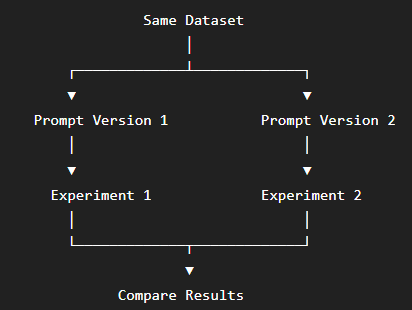

In [5]:
from dotenv import load_dotenv
load_dotenv()

from langsmith import Client
from langsmith.evaluation import evaluate

# =====================================================
# Create Dataset
# =====================================================

client = Client()

DATASET_NAME = "Prompt Comparison Demo"

try:

    dataset = client.create_dataset(
        dataset_name=DATASET_NAME
    )

    client.create_examples(

        dataset_id=dataset.id,

        inputs=[
            {"question":"What is Python?"},
            {"question":"What is AI?"}
        ],

        outputs=[
            {"answer":"Python is a programming language."},
            {"answer":"AI is the simulation of human intelligence."}
        ]
    )

except Exception:
    print("Dataset already exists.")

# =====================================================
# Prompt Version 1
# =====================================================

def app_prompt_v1(inputs):

    question = inputs["question"]

    prompt = f"""
Answer briefly.

Question:
{question}
"""

    # Simulated LLM
    if "Python" in question:
        answer = "Python is a programming language."

    else:
        answer = "AI is human intelligence simulation."

    return {
        "answer":answer
    }

# =====================================================
# Prompt Version 2
# =====================================================

def app_prompt_v2(inputs):

    question = inputs["question"]

    prompt = f"""
Answer accurately.

Use complete sentences.

Do not hallucinate.

Question:
{question}
"""

    # Simulated LLM

    if "Python" in question:

        answer = "Python is a high-level programming language."

    else:

        answer = "Artificial Intelligence is the simulation of human intelligence by machines."

    return {
        "answer":answer
    }

# =====================================================
# Exact Match Evaluator
# =====================================================

def exact_match(outputs, reference_outputs):

    return {

        "key":"Exact Match",

        "score":
            outputs["answer"] ==
            reference_outputs["answer"]
    }

# =====================================================
# Run Prompt V1
# =====================================================

evaluate(

    app_prompt_v1,

    data=DATASET_NAME,

    evaluators=[exact_match],

    experiment_prefix="Prompt-V1"
)

# =====================================================
# Run Prompt V2
# =====================================================

evaluate(

    app_prompt_v2,

    data=DATASET_NAME,

    evaluators=[exact_match],

    experiment_prefix="Prompt-V2"
)

print("Completed")

View the evaluation results for experiment: 'Prompt-V1-6457dfa6' at:
https://smith.langchain.com/o/fa3d1324-37d3-4d19-bf7e-c4846aca8587/datasets/69d63acc-fa20-449d-a0a0-70f326d5a94b/compare?selectedSessions=d88f7736-b7a7-469d-9cd3-26b8f22099a9




2it [00:00,  4.20it/s]


View the evaluation results for experiment: 'Prompt-V2-c1ab2328' at:
https://smith.langchain.com/o/fa3d1324-37d3-4d19-bf7e-c4846aca8587/datasets/69d63acc-fa20-449d-a0a0-70f326d5a94b/compare?selectedSessions=1f1815f5-6646-4579-b3bb-52d3a4ad0ecf




2it [00:00,  5.16it/s]

Completed


## Production monitoring

In [6]:
from dotenv import load_dotenv
load_dotenv()

import time
import random
from langsmith import traceable

# ==========================================================
# Step 1 : Embedding
# ==========================================================

@traceable(
    name="Embedding",
    run_type="embedding"
)
def create_embedding(question):

    time.sleep(0.4)

    embedding = [0.23, 0.51, 0.87]

    return embedding


# ==========================================================
# Step 2 : Vector Search
# ==========================================================

@traceable(
    name="Vector Search",
    run_type="retriever"
)
def retrieve_documents(embedding):

    time.sleep(0.5)

    docs = [
        "Alarm Logger Manager is configured from Application Bar.",
        "Figure 8-12 explains Alarm Logger configuration."
    ]

    return docs


# ==========================================================
# Step 3 : Prompt Builder
# ==========================================================

@traceable(
    name="Prompt Builder",
    run_type="prompt"
)
def build_prompt(question, docs):

    time.sleep(0.1)

    context = "\n".join(docs)

    prompt = f"""
Answer ONLY using the supplied context.

Context:
{context}

Question:
{question}

Answer:
"""

    return prompt


# ==========================================================
# Step 4 : LLM
# ==========================================================

@traceable(
    name="LLM",
    run_type="llm"
)
def call_llm(prompt):

    time.sleep(random.uniform(1,3))

    answer = (
        "Refer to Figure 8-12 for Alarm Logger Manager configuration."
    )

    return answer


# ==========================================================
# Step 5 : Production Pipeline
# ==========================================================

@traceable(
    name="Production RAG",
    run_type="chain"
)
def rag_pipeline(question):

    embedding = create_embedding(question)

    docs = retrieve_documents(embedding)

    prompt = build_prompt(question, docs)

    answer = call_llm(prompt)

    return answer


# ==========================================================
# Simulated Production Traffic
# ==========================================================

questions = [

    "Which figure should I refer for Alarm Logger Manager?",

    "How do I configure Application Bar?",

    "What is Alarm Logger?",

    "Explain History Viewer."

]

for i, question in enumerate(questions):

    print("="*80)
    print("User Question:", question)

    try:

        answer = rag_pipeline(

            question,

            langsmith_extra={

                "metadata":{

                    "environment":"Production",

                    "application":"ABB-RAG",

                    "user_id":f"user_{i+1}",

                    "version":"v1.0.0"
                }
            }
        )

        print("Answer:", answer)

    except Exception as e:

        print(e)

print("\nCompleted")

User Question: Which figure should I refer for Alarm Logger Manager?
Answer: Refer to Figure 8-12 for Alarm Logger Manager configuration.
User Question: How do I configure Application Bar?
Answer: Refer to Figure 8-12 for Alarm Logger Manager configuration.
User Question: What is Alarm Logger?
Answer: Refer to Figure 8-12 for Alarm Logger Manager configuration.
User Question: Explain History Viewer.
Answer: Refer to Figure 8-12 for Alarm Logger Manager configuration.

Completed


## FeedBack


In [7]:
from dotenv import load_dotenv
load_dotenv()

from langsmith import traceable, Client

client = Client()

# ==========================================================
# Simple Chatbot
# ==========================================================

@traceable(
    name="Simple Chatbot",
    run_type="chain"
)
def chatbot(question):

    if "Python" in question:
        return "Python is a programming language."

    return "I don't know."

# ==========================================================
# Execute Chatbot
# ==========================================================

result = chatbot(
    "What is Python?",
    langsmith_extra={
        "on_end": lambda run: client.create_feedback(
            run_id=run.id,
            key="user_rating",
            score=5.0,
            comment="Excellent answer!"
        )
    }
)

print(result)
print("Feedback submitted successfully!")

Python is a programming language.
Feedback submitted successfully!


## PlayGround

In [8]:
from dotenv import load_dotenv
load_dotenv()

import ollama
from langsmith import traceable

@traceable(name="Playground Demo", run_type="llm")
def ask_llm(question):

    prompt = f"""
Answer briefly.

Question:
{question}
"""

    response = ollama.chat(
        model="qwen3:8b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response["message"]["content"]

answer = ask_llm("What is LangSmith?")

print(answer)

LangSmith is a platform for developing and testing large language models (LLMs), offering tools for data labeling, model training, evaluation, and integration with other AI development tools.
